# Shot Conversion Rate By Distance for 21/22 NHL Season

In this project, I used data analysis techniques in pandas to map **goal 
efficiency with respect to distance from the net**

## Goal

My objective for this project was not to simply map goal efficiency once, but to map it many different types of ways, and see 
how shot data can be interpreted based on **what factors I isolate and determine are necessary for my visualization**. 

If you don't know already, shot distance is one of the most important variables in hockey analytics. This is because shots taken closer to the net generally have a higher probability of becoming goals. Key word is "generally", as there are many game states in hockey, including the empty-net. 

The empty-net shot occurs usually towards the end of the game to give the losing team a chance to score with one extra skater, at the cost of their goalie.

The data provided is from Kaggle, and can be found here:
https://www.kaggle.com/datasets/mexwell/national-hockey-league-shots?resource=download

This dataset contains over 160,000 shot attempts from NHL games during the 2021-2022 season

In being new to pandas, I decided to include my **process as a whole**, so there will be a lot of 
retyping the same lines of code.

To start with, df is the variable name for our NHL shots data, and the .head() follows pandas sequential nature.
**df.head() reads as follows: "Show me the top 5 rows of the data frame/table known as df"**

In [320]:
import pandas as pd

df = pd.read_csv("nhl-shots-2021.csv")
df.head()

,game_id,description,shot_outcome,period,period_seconds_remaining,game_seconds_remaining,home_score,away_score,home_name,away_name,...,empty_net,event_player_1_name,event_player_1_type,event_player_2_name,event_player_2_type,strength_code,x_fixed,y_fixed,shot_distance,shot_angle
0,2021020001,Steven Stamkos Wrist Shot saved by Tristan Jarry,SHOT,1,1137,3537,0,0,Tampa Bay Lightning,Pittsburgh Penguins,...,NaN,Steven.Stamkos,Shooter,Tristan.Jarry,Goalie,EV,61.0,-32.0,42.5,48.8
1,2021020001,Zach Bogosian shot blocked shot by Brock McGinn,BLOCKED_SHOT,1,1115,3515,0,0,Tampa Bay Lightning,Pittsburgh Penguins,...,NaN,Zach.Bogosian,Shooter,Brock.McGinn,Blocker,EV,60.0,-17.0,NaN,NaN
2,2021020001,Brock McGinn Wrist Shot saved by Andrei Vasile...,SHOT,1,1096,3496,0,0,Tampa Bay Lightning,Pittsburgh Penguins,...,NaN,Brock.McGinn,Shooter,Andrei.Vasilevskiy,Goalie,EV,-65.0,19.0,30.6,38.4
3,2021020001,Jan Rutta Wrist Shot saved by Tristan Jarry,SHOT,1,1079,3479,0,0,Tampa Bay Lightning,Pittsburgh Penguins,...,NaN,Jan.Rutta,Shooter,Tristan.Jarry,Goalie,EV,-8.0,-27.0,100.7,15.6
4,2021020001,Danton Heinen Wrist Shot saved by Andrei Vasil...,SHOT,1,1033,3433,0,0,Tampa Bay Lightning,Pittsburgh Penguins,...,NaN,Danton.Heinen,Shooter,Andrei.Vasilevskiy,Goalie,EV,-60.0,-4.0,29.3,7.9


## Part I: Gathering Data Info

First thing to do is to look at what columns we have, so we can determine what data we can manipulate.
Since our objective is based on goals with respect to distance, our key columns are as follows:

*shot_outcome*, 
*shot_distance*, 
and "*is_goal*", which will be created later

In [321]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160573 entries, 0 to 160572
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   game_id                   160573 non-null  int64  
 1   description               160573 non-null  object 
 2   shot_outcome              160573 non-null  object 
 3   period                    160573 non-null  int64  
 4   period_seconds_remaining  160573 non-null  int64  
 5   game_seconds_remaining    160573 non-null  int64  
 6   home_score                160573 non-null  int64  
 7   away_score                160573 non-null  int64  
 8   home_name                 160573 non-null  object 
 9   away_name                 160573 non-null  object 
 10  event_team                160573 non-null  object 
 11  event_goalie_name         89064 non-null   object 
 12  empty_net                 8712 non-null    object 
 13  event_player_1_name       160573 non-null  o

shot_outcome can be interpreted as a table in and of itself. Each shot has the potential to be a goal, but is mostly just 
a shot, which is why it's important to count the individual values and see how we can equate shot_outcome and is_goal to a 
goal, specifically. Python needs proper syntax to find the right value, so *'Goal' would not work*.

TL;DR we are only evaluating GOAL outcomes, and it's important that we **type goal in all caps**, as that is how the df["shot_outcome"] reads goals as.

In [322]:
df["shot_outcome"].value_counts()

shot_outcome
SHOT            80648
BLOCKED_SHOT    38224
MISSED_SHOT     32765
GOAL             8936
Name: count, dtype: int64

The first step is creating a new column called is_goal. **This column returns a bool, as shot_outcome is either a 
GOAL or not a GOAL**

In [323]:
df["is_goal"] = df["shot_outcome"] == "GOAL"

Interestingly enough, I believe that you're able to find the mean of the is_goal column as *True=1 and False=0*. As a result, 
we can use this fact to map each teams goal efficiency vs shot attempts, as well as the league average efficiency.

In [324]:
df["is_goal"].mean()

np.float64(0.05565070092730409)

In [325]:
team_goal_rate = df.groupby("event_team")["is_goal"].mean().sort_values(ascending=False)

In [326]:
team_goal_rate.head(10)

event_team
St. Louis Blues        0.072127
Minnesota Wild         0.064762
Toronto Maple Leafs    0.061889
Tampa Bay Lightning    0.060945
Florida Panthers       0.060431
Colorado Avalanche     0.060281
Washington Capitals    0.059713
Edmonton Oilers        0.059607
New York Rangers       0.059146
Nashville Predators    0.058562
Name: is_goal, dtype: float64

## Part II: Data Refinement

In this section, I determined the null values in df and inspected columns within it. This is so I can determine whether or not
plotting goal efficiency vs distance is possible given the data within df.

As can be seen, shot_distance is up there for null values with shot_distance. This is okay, though,
as y_fixed and x_fixed for each shot is near complete, meaning shot distance could be deduced if necessary.

I continued with the project as shot_outcome is fully known, meaning for every shot that is known
to be a goal, it is safe to assume that there is a shot distance attached to it.

In [327]:
df.isnull().sum().sort_values(ascending=False).head(10)

empty_net              151861
event_goalie_name       71509
shot_angle              38224
shot_distance           38224
event_player_2_type       374
event_player_2_name       374
strength_code             306
y_fixed                    13
x_fixed                    13
event_player_1_type         0
dtype: int64

In [328]:
df["shot_distance"].describe()

count    122349.000000
mean         35.198477
std          24.087589
min           1.000000
25%          17.100000
50%          32.000000
75%          48.500000
max         189.200000
Name: shot_distance, dtype: float64

In [329]:
df["shot_distance"].max()

189.2

In [330]:
df["shot_distance"].min()

1.0

In [331]:
df["y_fixed"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 160573 entries, 0 to 160572
Series name: y_fixed
Non-Null Count   Dtype  
--------------   -----  
160560 non-null  float64
dtypes: float64(1)
memory usage: 1.2 MB


In [332]:
df["x_fixed"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 160573 entries, 0 to 160572
Series name: x_fixed
Non-Null Count   Dtype  
--------------   -----  
160560 non-null  float64
dtypes: float64(1)
memory usage: 1.2 MB


In [333]:
df.shape

(160573, 23)

In [334]:
df.columns

Index(['game_id', 'description', 'shot_outcome', 'period',
       'period_seconds_remaining', 'game_seconds_remaining', 'home_score',
       'away_score', 'home_name', 'away_name', 'event_team',
       'event_goalie_name', 'empty_net', 'event_player_1_name',
       'event_player_1_type', 'event_player_2_name', 'event_player_2_type',
       'strength_code', 'x_fixed', 'y_fixed', 'shot_distance', 'shot_angle',
       'is_goal'],
      dtype='object')

## Part III: Rounded Distance

With all the introductory knowledge out of the way, I started to group data based on the rounded distance.
As shot_distance was measure to the decimal, I thought it was better to group shots based on their rounded distance.
This is as it would be difficult to see trends in efficiency if the distance was too specific/localized.

In [335]:
df["distance_rounded"] = df["shot_distance"].round(0)

In [336]:
distance_counts = df["distance_rounded"].value_counts().sort_index()
distance_counts.head(20)

distance_rounded
1.0        8
2.0       18
3.0       43
4.0      342
5.0      602
6.0     1410
7.0     1925
8.0     3222
9.0     3061
10.0    3205
11.0    3090
12.0    2786
13.0    2368
14.0    2613
15.0    2081
16.0    2478
17.0    1794
18.0    2408
19.0    2008
20.0    2042
Name: count, dtype: int64

In [337]:
distance_counts.tail(20)

distance_rounded
170.0    30
171.0    30
172.0    23
173.0    22
174.0    28
175.0    28
176.0    22
177.0    23
178.0    33
179.0    23
180.0    38
181.0    21
182.0    42
183.0    21
184.0    32
185.0    37
186.0    19
187.0    16
188.0     5
189.0     1
Name: count, dtype: int64

In [338]:
df.groupby("distance_rounded")["is_goal"].mean()

distance_rounded
1.0      0.625000
2.0      0.500000
3.0      0.418605
4.0      0.248538
5.0      0.197674
           ...   
185.0    0.081081
186.0    0.105263
187.0    0.000000
188.0    0.000000
189.0    0.000000
Name: is_goal, Length: 189, dtype: float64

**.agg()** helped me create further columns within df by assigning attempts and goals to each particular rounded distance.
If done using python, I most likely would have had to create a for loop that inputted *attempts, goals, and goal rate*
based on a dictionary created from distance_rounded.

In [339]:
distance_summary = df.groupby("distance_rounded").agg(
    attempts=("is_goal","size"),
    goals=("is_goal","sum"),
    goal_rate=("is_goal","mean")
)

In [340]:
distance_summary.head(15)

,attempts,goals,goal_rate
distance_rounded,,,
1.0,8,5,0.625000
2.0,18,9,0.500000
3.0,43,18,0.418605
4.0,342,85,0.248538
5.0,602,119,0.197674
6.0,1410,253,0.179433
7.0,1925,335,0.174026
8.0,3222,526,0.163253
9.0,3061,464,0.151584


In [341]:
distance_summary.tail(15)

,attempts,goals,goal_rate
distance_rounded,,,
175.0,28,1,0.035714
176.0,22,0,0.000000
177.0,23,0,0.000000
178.0,33,2,0.060606
179.0,23,1,0.043478
180.0,38,3,0.078947
181.0,21,1,0.047619
182.0,42,5,0.119048
183.0,21,2,0.095238


In [342]:
distance_summary.sort_values("attempts").head(10)

,attempts,goals,goal_rate
distance_rounded,,,
189.0,1,0,0.000000
188.0,5,0,0.000000
1.0,8,5,0.625000
117.0,11,1,0.090909
121.0,12,1,0.083333
115.0,13,1,0.076923
118.0,15,0,0.000000
119.0,15,0,0.000000
187.0,16,0,0.000000


**I decided to filter out distances that had less than 200 shot attempts**, as there were many distances further away 
from the net that had excellent efficiency. Unfortunately, **these attempts represent an "empty-net" situation**, which
is where the goalie of a team is not in the net, enabling long shots to have a higher rate of becoming a "GOAL".

In [343]:
distance_summary_filtered = distance_summary[distance_summary["attempts"] >= 200]

In [344]:
distance_summary_filtered.tail(10)

,attempts,goals,goal_rate
distance_rounded,,,
59.0,1234,30,0.024311
60.0,1606,30,0.018680
61.0,908,12,0.013216
62.0,889,14,0.015748
63.0,682,11,0.016129
64.0,774,14,0.018088
65.0,446,11,0.024664
66.0,408,9,0.022059
67.0,285,4,0.014035


Filtering for 200 shot attempts, the goal conversion rate follows an exponential decay. Meaning, **the farther away
a shooter is from the net, the less likely their shot results in a goal**. This does not mean that the percentage 
of a long shot is fully 0, though, which is where empty-net shots come into play. 

Text(0, 0.5, 'Goal Conversion Rate')

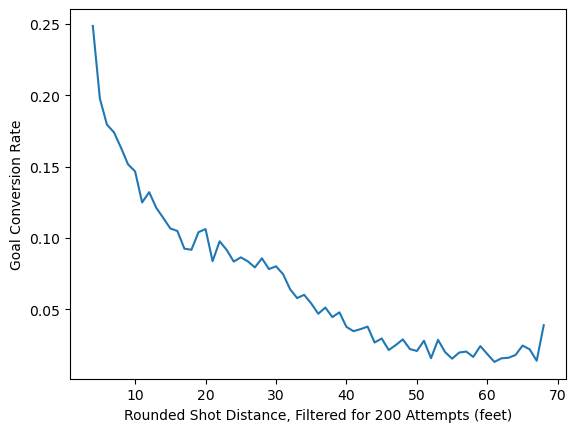

In [345]:
ax = distance_summary_filtered["goal_rate"].plot()
ax.set_xlabel("Rounded Shot Distance, Filtered for 200 Attempts (feet)")
ax.set_ylabel("Goal Conversion Rate")

## Part IV: Distance Buckets

Here, I decided to go one step further. Instead of simply filtering the shots by rounded distance,
I split the rounded distance into intervals, where goal conversion data would fall into.
**I found this method to be more accurate as rounded distance had a lot of "noise"**, as can be seen
with the lack of continuity in goal conversion rate over rounded distance.

First step was to create my intervals and assign shot_distance *(no longer rounded)* to each bin and label.
Second step was to create the same sort of df I made with [distance_summary], that aggregated attempts, goals, and
goal rate, based on [shot_distance].

In [346]:
bins = [0,10,20,30,40,50,60,70,80,90,200]

labels = [
    "0-10","10-20","20-30","30-40","40-50","50-60","60-70","70-80","80-90","90+"
]

df["distance_bucket"] = pd.cut(
    df["shot_distance"],
    bins=bins,
    labels=labels
    )

In [347]:
bucket_summary = df.groupby("distance_bucket", observed=True).agg(
    attempts=("is_goal","size"),
    goals=("is_goal","sum"),
    goal_rate=("is_goal","mean")
)

In [348]:
type(bucket_summary)

pandas.core.frame.DataFrame

In [349]:
bucket_summary.head()

,attempts,goals,goal_rate
distance_bucket,,,
0-10,12790,2141,0.167396
10-20,23813,2690,0.112964
20-30,20524,1764,0.085948
30-40,20093,1134,0.056438
40-50,17020,501,0.029436


Plotting goal conversion rate vs. 10 feet distance buckets, the data almost seems too smooth,
too parabolic. I was not a fan of this result, as the reality says otherwise. 

**Reality: A shot from 60-70 most likely involves a goalie in net. Anything above 90 feet is most likely
an empty-net attempt**

As a result, I had to go back to the drawing board to see how else to visualize the goal conversion rate.

Text(0, 0.5, 'Goal Conversion Rate')

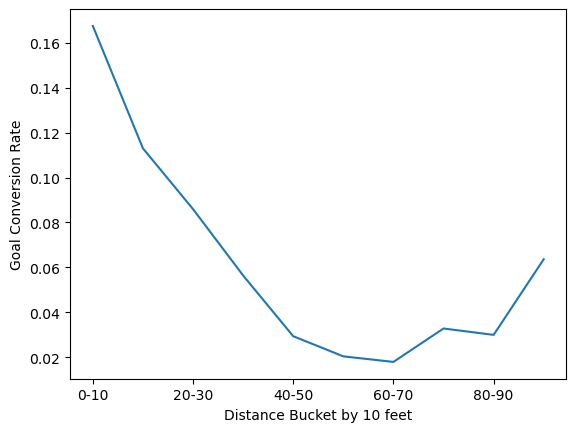

In [350]:
ax = bucket_summary["goal_rate"].plot()
ax.set_xlabel("Distance Bucket by 10 feet")
ax.set_ylabel("Goal Conversion Rate")

In [351]:
bucket_summary = df.groupby("distance_bucket", observed=True).agg(
    attempts=("is_goal","size"),
    goals=("is_goal","sum"),
    goal_rate=("is_goal","mean")
)

In [352]:
bucket_summary.head()

,attempts,goals,goal_rate
distance_bucket,,,
0-10,12790,2141,0.167396
10-20,23813,2690,0.112964
20-30,20524,1764,0.085948
30-40,20093,1134,0.056438
40-50,17020,501,0.029436


I decided to re-plot the goal conversion rate vs distance bucket as a bar graph, as I could better visualize
the distances that were causing the parabolic behavior. In the plot shown below, I found that the conversion
rate of shots from 90 feet to 200 feet(full ice length) were higher than those buckets much closer to the net, 
notably the 40-70 foot range.

**This result confirmed the idea that empty-net shots are skewing the data and making it seem like a shot from
90+ feet out is a better shot.** 
The truth is that you are more likely to see an empty-net goal go in from 90+ feet, rather.

Text(0, 0.5, 'Goal Conversion Rate')

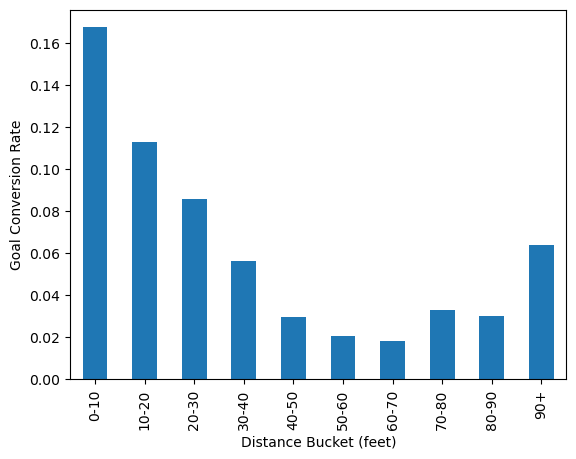

In [353]:
bx = bucket_summary["goal_rate"].plot(kind="bar")
bx.set_xlabel("Distance Bucket (feet)")
bx.set_ylabel("Goal Conversion Rate")

## Part V: Accounting for Empty Net Shots

**I knew that the data I was working with would no longer map "true shooting pct."** as empty-net shots are a completely different game state.
As a result, I found that the data I was mapping was truly **Goal conversion rate based on distance from the net**. 

**The next questions I had to ask myself, then, was how well were empty net goals converted on from 90-200 feet?**

In [354]:
df[df["shot_distance"] >= 90].head()

,game_id,description,shot_outcome,period,period_seconds_remaining,game_seconds_remaining,home_score,away_score,home_name,away_name,...,event_player_2_name,event_player_2_type,strength_code,x_fixed,y_fixed,shot_distance,shot_angle,is_goal,distance_rounded,distance_bucket
3,2021020001,Jan Rutta Wrist Shot saved by Tristan Jarry,SHOT,1,1079,3479,0,0,Tampa Bay Lightning,Pittsburgh Penguins,...,Tristan.Jarry,Goalie,EV,-8.0,-27.0,100.7,15.6,False,101.0,90+
47,2021020001,Victor Hedman Wrist Shot saved by Tristan Jarry,SHOT,2,892,2092,0,2,Tampa Bay Lightning,Pittsburgh Penguins,...,Tristan.Jarry,Goalie,EV,-31.0,20.0,121.7,9.5,False,122.0,90+
94,2021020001,Victor Hedman Wrist Shot saved by Tristan Jarry,SHOT,3,500,500,0,3,Tampa Bay Lightning,Pittsburgh Penguins,...,Tristan.Jarry,Goalie,EV,-8.0,35.0,103.1,19.8,False,103.0,90+
107,2021020001,"Evan Rodrigues (1) Wrist Shot, assists: John M...",GOAL,3,145,145,2,5,Tampa Bay Lightning,Pittsburgh Penguins,...,John.Marino,Assist,SH,31.0,32.0,124.2,14.9,True,124.0,90+
108,2021020001,"Bryan Rust (1) Wrist Shot, assists: none",GOAL,3,109,109,2,6,Tampa Bay Lightning,Pittsburgh Penguins,...,NaN,NaN,SH,24.0,10.0,113.4,5.1,True,113.0,90+


The next lines of code reads as follows: For shot distances within df at least 90 feet out, count the given values
of shot outcome, and describe shot distance data for shots at least 90 feet out.

In [355]:
df[df["shot_distance"] >= 90]["shot_outcome"].value_counts()

shot_outcome
SHOT           2397
MISSED_SHOT     266
GOAL            180
Name: count, dtype: int64

In [356]:
df[df["shot_distance"] >= 90]["shot_distance"].describe()

count    2843.000000
mean      136.323426
std        30.018630
min        90.000000
25%       107.200000
50%       138.000000
75%       162.000000
max       189.200000
Name: shot_distance, dtype: float64

I then tried to find out how many of these long shots were empty net attempts. **Truthfully, not many, but I do note that not many shots happened from that distance, compared to the whole dataset.**
As a result, I decided to increase the distance buckets to map goal conversion rate over further subdivided distance buckets.

In [357]:
df[df["shot_distance"] >= 90][["shot_distance", "shot_outcome", "empty_net"]].head(20)

,shot_distance,shot_outcome,empty_net
3,100.7,SHOT,NaN
47,121.7,SHOT,NaN
94,103.1,SHOT,NaN
107,124.2,GOAL,True
108,113.4,GOAL,True
174,153.9,SHOT,NaN
287,138.1,SHOT,NaN
328,173.4,MISSED_SHOT,NaN
386,142.4,MISSED_SHOT,NaN
461,96.2,SHOT,NaN


In [358]:
bins = [0,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,200]

labels = [
    "0-10","10-20","20-30","30-40","40-50",
    "50-60","60-70","70-80","80-90",
    "90-100","100-110","110-120","120-130",
    "130-140","140-150","150-160","160-170",
    "170-180","180+"
]

df["distance_bucket"] = pd.cut(
    df["shot_distance"],
    bins=bins,
    labels=labels
)

In [359]:
bucket_summary = df.groupby("distance_bucket", observed=True).agg(
    attempts=("is_goal","size"),
    goals=("is_goal","sum"),
    goal_rate=("is_goal","mean")
)

In [360]:
bucket_summary

,attempts,goals,goal_rate
distance_bucket,,,
0-10,12790,2141,0.167396
10-20,23813,2690,0.112964
20-30,20524,1764,0.085948
30-40,20093,1134,0.056438
40-50,17020,501,0.029436
50-60,17725,363,0.020480
60-70,5554,100,0.018005
70-80,1004,33,0.032869
80-90,999,30,0.030030


Text(0, 0.5, 'Goal Conversion Rate')

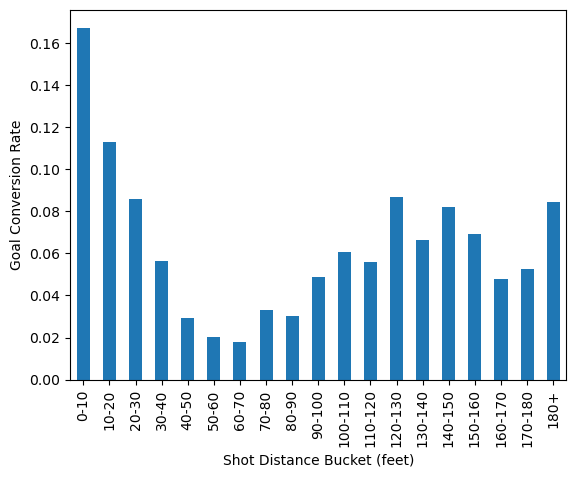

In [361]:
cx = bucket_summary["goal_rate"].plot(kind="bar")
cx.set_xlabel("Shot Distance Bucket (feet)")
cx.set_ylabel("Goal Conversion Rate")

Instead of writing out bins and labels as a list, like I did before, I decided to run loops that inputted the data based on 
a range. (0, 210, 10) means "starting at 0, ending at 200, going up by 10".

In [363]:
bins = list(range(0, 210, 10))
labels = [f"{i}--{i+10}" for i in range (0, 200, 10)]

df["distance_bucket_by10"] = pd.cut(
    df["shot_distance"],
    bins=bins,
    labels=labels
)

In [364]:
bucket_summary_by10 = df.groupby("distance_bucket_by10", observed=True).agg(
    attempts=("is_goal","size"),
    goals=("is_goal","sum"),
    goal_rate=("is_goal","mean")
)

In [365]:
bucket_summary_by10

,attempts,goals,goal_rate
distance_bucket_by10,,,
0--10,12790,2141,0.167396
10--20,23813,2690,0.112964
20--30,20524,1764,0.085948
30--40,20093,1134,0.056438
40--50,17020,501,0.029436
50--60,17725,363,0.020480
60--70,5554,100,0.018005
70--80,1004,33,0.032869
80--90,999,30,0.030030


Text(0, 0.5, 'Goal Conversion Rate')

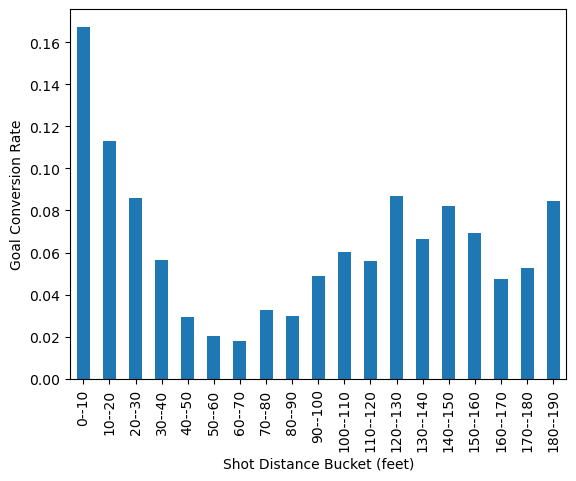

In [366]:
dx = bucket_summary_by10["goal_rate"].plot(kind="bar")
dx.set_xlabel("Shot Distance Bucket (feet)")
dx.set_ylabel("Goal Conversion Rate")

## Part VI: Conclusion

The analysis shows that as shot distance increases, goal probability does not necessarily decrease. In fact, given the empty-net game state, shots from more than 100 feet out can be expected to go in given the right circumstances.

If one would like to see true shooting percentage on a goalie, one would have to remove the empty net shots entirely, and an exponential decay would most likely be seen, as in Part III.

This type of analysis is a simplified version of what is used in more advanced hockey analytics models such as expected goals (xG), but I also wonder if empty-net shots are factored into xG.
